In [1]:
# Load necessary libraries
import os
import glob
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from timm import create_model
import numpy as np

In [2]:
# Hyperparameters
batch_size = 16
learning_rate = 1e-4
num_epochs = 10
num_classes = 7  # IED + 6 TrashNet categories
image_size = 224
num_workers = 0  # Disable multiprocessing

In [3]:
# Define CombinedDataset class
class CombinedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading image {self.image_paths[idx]}: {str(e)}")
            return None

In [4]:
# Define Data loading functions
def load_ied_data(base_path):
    print(f"Loading IED data from {base_path}...")
    data = {}
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, split)
        image_paths = glob.glob(os.path.join(split_path, '*.*'))
        labels = [0] * len(image_paths)
        data[split] = (image_paths, labels)
        print(f"  IED {split} set: {len(image_paths)} images")
    return data

def load_trashnet_data(base_path):
    print(f"Loading TrashNet data from {base_path}...")
    image_paths = []
    labels = []
    label_map = {'glass': 1, 'paper': 2, 'cardboard': 3, 'plastic': 4, 'metal': 5, 'trash': 6}
    for category in os.listdir(base_path):
        category_path = os.path.join(base_path, category)
        if os.path.isdir(category_path):
            category_images = glob.glob(os.path.join(category_path, '*.*'))
            image_paths.extend(category_images)
            labels.extend([label_map[category]] * len(category_images))
            print(f"  TrashNet {category}: {len(category_images)} images")
    return image_paths, labels

In [5]:
# Define Validation function
def validate(model, data_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_loader:
            if batch is None:
                continue
            images, labels = batch
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss /= len(data_loader)
    val_accuracy = 100 * correct / total
    return val_accuracy, val_loss

In [6]:
# Define Collate function
def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return images, labels

Starting the waste detection program...
Checking directories...
Directories found successfully.
Loading data...
Loading IED data from C:\Users\nisin\OneDrive\Documents\MIT\MDA522 Artificial Intelligence\Assignments\Assignment 2\ied_data...
  IED train set: 1768 images
  IED val set: 24 images
  IED test set: 26 images
Loading TrashNet data from C:\Users\nisin\OneDrive\Documents\MIT\MDA522 Artificial Intelligence\Assignments\Assignment 2\trashnet_data...
  TrashNet cardboard: 403 images
  TrashNet glass: 501 images
  TrashNet metal: 410 images
  TrashNet paper: 594 images
  TrashNet plastic: 482 images
  TrashNet trash: 137 images
Splitting TrashNet data...
Combining IED and TrashNet data...
Total training samples: 3536
Total validation samples: 403
Total test samples: 406
Setting up data transforms...
Creating datasets...
Creating data loaders...
Creating Swin Transformer model for transfer learning...
Using device: cpu
Setting up loss function and optimizer...
Starting training...
Epo

Batch 81: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 82: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 83: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 84: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 85: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 86: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 87: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 88: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 89: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 90/221, Loss: 0.4243
Batch 90: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 91: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 92: Images shape: t

Batch 173: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 174: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 175: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 176: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 177: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 178: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 179: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 180/221, Loss: 0.0476
Batch 180: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 181: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 182: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 183: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 184: Im

Batch 42: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 43: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 44: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 45: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 46: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 47: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 48: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 49: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 50/221, Loss: 0.0005
Batch 50: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 51: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 52: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 53: Images shape: t

Batch 134: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 135: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 136: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 137: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 138: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 139: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 140/221, Loss: 0.0595
Batch 140: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 141: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 142: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 143: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 144: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 145: Im

...

Batch 12: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 13: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 14: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 15: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 16: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 17: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 18: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 19: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 20/221, Loss: 0.0005
Batch 20: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 21: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 22: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 23: Images shape: t

Batch 105: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 106: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 107: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 108: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 109: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 110/221, Loss: 0.0024
Batch 110: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 111: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 112: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 113: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 114: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 115: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 116: Im

Batch 197: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 198: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 199: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
  Batch 200/221, Loss: 0.0018
Batch 200: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 201: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 202: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 203: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 204: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 205: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 206: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 207: Images shape: torch.Size([16, 3, 224, 224]), Labels shape: torch.Size([16])
Batch 208: Im

C:\Users\nisin\AppData\Local\Temp\ipykernel_11372\3009054469.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_waste_detection_mod

Calculating metrics...
Test Accuracy: 0.9507
Precision: 0.9519
Recall: 0.9507
F1 Score: 0.9507
Plotting confusion matrix...


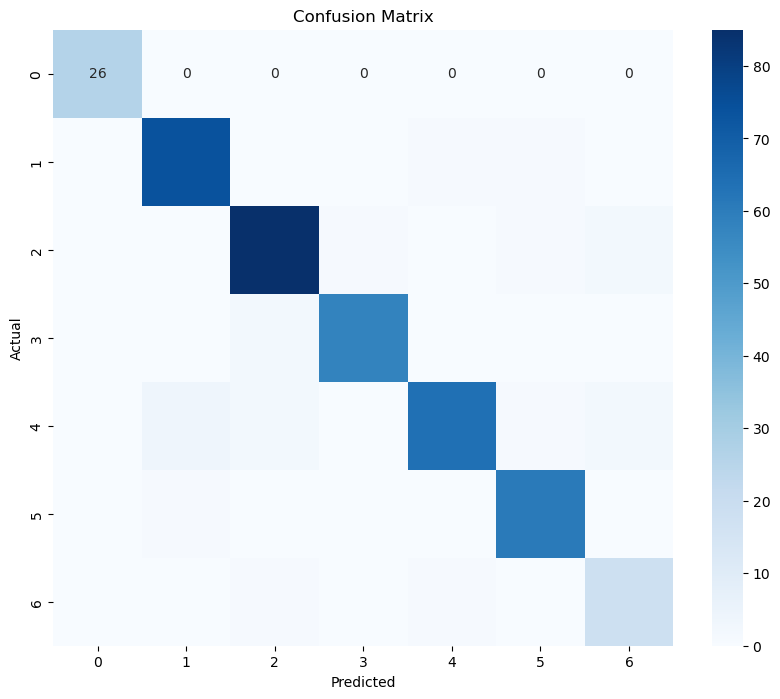

Program completed successfully.


In [7]:
# Training

if __name__ == "__main__":
    try:
        print("Starting the waste detection program...")
        
        base_dir = r'C:\Users\nisin\OneDrive\Documents\MIT\MDA522 Artificial Intelligence\Assignments\Assignment 2'
        ied_dir = os.path.join(base_dir, 'ied_data')
        trashnet_dir = os.path.join(base_dir, 'trashnet_data')

        print("Checking directories...")
        if not os.path.exists(ied_dir):
            raise FileNotFoundError(f"IED directory not found: {ied_dir}")
        if not os.path.exists(trashnet_dir):
            raise FileNotFoundError(f"TrashNet directory not found: {trashnet_dir}")
        print("Directories found successfully.")

        print("Loading data...")
        ied_data = load_ied_data(ied_dir)
        trashnet_paths, trashnet_labels = load_trashnet_data(trashnet_dir)
        
        print("Splitting TrashNet data...")
        trashnet_train_paths, trashnet_temp_paths, trashnet_train_labels, trashnet_temp_labels = train_test_split(
            trashnet_paths, trashnet_labels, test_size=0.3, stratify=trashnet_labels, random_state=42
        )
        trashnet_val_paths, trashnet_test_paths, trashnet_val_labels, trashnet_test_labels = train_test_split(
            trashnet_temp_paths, trashnet_temp_labels, test_size=0.5, stratify=trashnet_temp_labels, random_state=42
        )
        
        print("Combining IED and TrashNet data...")
        train_paths = ied_data['train'][0] + trashnet_train_paths
        train_labels = ied_data['train'][1] + trashnet_train_labels
        val_paths = ied_data['val'][0] + trashnet_val_paths
        val_labels = ied_data['val'][1] + trashnet_val_labels
        test_paths = ied_data['test'][0] + trashnet_test_paths
        test_labels = ied_data['test'][1] + trashnet_test_labels

        print(f"Total training samples: {len(train_paths)}")
        print(f"Total validation samples: {len(val_paths)}")
        print(f"Total test samples: {len(test_paths)}")

        print("Setting up data transforms...")
        transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        print("Creating datasets...")
        train_dataset = CombinedDataset(train_paths, train_labels, transform)
        val_dataset = CombinedDataset(val_paths, val_labels, transform)
        test_dataset = CombinedDataset(test_paths, test_labels, transform)

        print("Creating data loaders...")
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

        print("Creating Swin Transformer model for transfer learning...")
        model = create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=num_classes)
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = model.to(device)
        print(f"Using device: {device}")

        print("Setting up loss function and optimizer...")
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

        print("Starting training...")
        best_val_accuracy = 0
        start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            print(f"Epoch {epoch+1}/{num_epochs}")
            model.train()
            train_loss = 0.0
            for batch_idx, batch in enumerate(train_loader):
                try:
                    if batch is None:
                        continue
                    images, labels = batch
                    print(f"Batch {batch_idx}: Images shape: {images.shape}, Labels shape: {labels.shape}")
                    images, labels = images.to(device), labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                    
                    train_loss += loss.item()
                    
                    if (batch_idx + 1) % 10 == 0:
                        print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
                except Exception as e:
                    print(f"Error in batch {batch_idx}: {str(e)}")
                    continue
            
            train_loss /= len(train_loader)
            
            print("Running validation...")
            val_accuracy, val_loss = validate(model, val_loader, criterion, device)
            
            epoch_time = time.time() - epoch_start_time
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {train_loss:.4f}, '
                  f'Val Loss: {val_loss:.4f}, '
                  f'Val Accuracy: {val_accuracy:.2f}%, '
                  f'Time: {epoch_time:.2f}s')
            
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                torch.save(model.state_dict(), 'best_waste_detection_model.pth')
                print(f"New best model saved with validation accuracy: {best_val_accuracy:.2f}%")

        total_time = time.time() - start_time
        print(f'Training completed. Total time: {total_time:.2f}s')
        print(f'Best validation accuracy: {best_val_accuracy:.2f}%')

        print("Evaluating on test set...")
        model.load_state_dict(torch.load('best_waste_detection_model.pth'))
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in test_loader:
                if batch is None:
                    continue
                images, labels = batch
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print("Calculating metrics...")
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
        conf_matrix = confusion_matrix(all_labels, all_preds)

        print(f'Test Accuracy: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1 Score: {f1:.4f}')

        print("Plotting confusion matrix...")
        plt.figure(figsize=(10, 8))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        print("Program completed successfully.")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()